# Goals

* Use GA2M for the analysis
* level of analysis changed to SKU, rather than ASIN
* Any ASIN having predictors of sales will be kept for further analysis


# Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_partregress_grid
import statsmodels.formula.api as smf

In [3]:
from sklearn.model_selection import train_test_split

## Utility functions

In [4]:
def plotting_predictions(ts_true,ts_pred,fig_title):
    plt.figure(figsize=(12,8))
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    
    plt.plot(ts_true,'-bo',label='Actual value')
    plt.plot(ts_pred,'-r^',label='Prediction value')
    
    plt.legend(loc='upper left',fontsize=15)
    plt.title(fig_title,fontsize=18)
    
    #rmse, mape, r2 = metrics_time_series(ts_true,ts_pred,verbose=False)
    #plt.text(.5,.96,f"RMSE : %.2f\nMAPE : %.2f\nR2  : %.2f" % (rmse,mape,r2), \
    #     bbox={'facecolor':'w','pad':5},
    #     ha="right", va="top", transform=plt.gca().transAxes,fontsize=15)
    rmse, mape, r2 = metrics_time_series(ts_true,ts_pred,verbose=False)
    plt.text(.5,.96,f"RMSE : %.2f\nMAPE : %.2f\nR2   : %.2f" % (rmse,mape,r2), \
         bbox={'facecolor':'w','pad':5},
         ha="left", va="top", transform=plt.gca().transAxes,fontsize=15)
    
    plt.show()

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics_time_series(y_true, y_pred,verbose=True):
    '''
    Compute the MAE and MSE metrics from sklearn.metrics
    @param y_true: (list) list of the true values
    @param y_pred: (list) list of predicted values
    @return rmse,mape,mae: (float), (float) values of metrics RMSE,MAPE, MAE
    '''
    rmse = round(np.sqrt(mean_squared_error(y_true, y_pred)), 2) 
    
    y_true_nz = y_true[(y_true!=0.0)] # non-zero true values (See denom.)
    mape = round(np.mean(np.abs((y_true_nz - y_pred[y_true_nz.index]) / y_true_nz)) * 100,2)
    
    #mae = round(mean_absolute_error(y_true, y_pred),2)
    r2 =  round(r2_score(y_true, y_pred), 2)
    
    if verbose:
        print(f"RMSE : {rmse}")
     #  print(f"MAE : {mae}")
        print(f"MAPE : {mape}")   
        print(f"R2   : {r2}")
    return rmse,mape,r2

# Data Wrangling

In [6]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"]="/Users/wphong/Desktop/Zinus/market-analysis-project-91130-f7b373249865.json"

import google.auth 

from google.cloud import bigquery

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [7]:
sql = """
select * from wook.fact_amz_mkt_all;
"""
# select zinus_sku_cd as sku, collection from `market-analysis-project-91130.meta.erp_sku_collection_220330`

df = bqclient.query(sql).to_dataframe()
df = df.drop_duplicates()
df

,asin,prdct_title,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,zinus_sku,collection,profile,size,yr_wk,rvw_cnt,star12_cnt,star12_ratio
0,B088N8J71Y,Beige Swatch,0.00,24,<NA>,0.000000,4,6.000000,0.000000,FSLTD-BG,None,None,None,202024,<NA>,<NA>,NaN
1,B088NP3K7P,Soft Grey Swatch,0.00,2,<NA>,0.000000,2,1.000000,0.000000,FB5432G,None,None,None,202029,<NA>,<NA>,NaN
2,B07HYVX2NZ,"Zinus Alto Table, White",220.58,1,436,220.580000,39,0.025641,0.000000,OLB-DT-AW47,OLB DT,None,None,202052,<NA>,<NA>,NaN
3,B07GGF5RFF,"Zinus Josh, Sofa, Beige",8331.46,25,72,333.258400,10703,0.002336,0.000000,SSTD-BG,SSTD,None,None,202030,4,2,0.5
4,B07GGF5RFF,"Zinus Josh, Sofa, Beige",25999.62,81,69,320.982963,15518,0.005220,0.000000,SSTD-BG,SSTD,None,None,202029,4,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174094,B07W8JQ5KR,Zinus Jared 14 Inch Metal Adjustable Bed Frame...,0.00,0,2160,NaN,237,0.000000,0.040486,ADB-14Q,ADB,14 Inch,Queen,202126,<NA>,<NA>,NaN
174095,B07VWL116L,Zinus Italian Made 12 Inch Olive Oil Pocket Sp...,0.00,0,145,NaN,47,0.000000,0.078431,ITA-OLIVE-12Q,OLIVE OIL,12 inch,Queen,202144,<NA>,<NA>,NaN
174096,B07VWL116L,Zinus Italian Made 12 Inch Olive Oil Pocket Sp...,5.08,0,363,NaN,277,0.000000,0.051370,ITA-OLIVE-12Q,OLIVE OIL,12 inch,Queen,202150,<NA>,<NA>,NaN
174097,B07VWL116L,Zinus Italian Made 12 Inch Olive Oil Pocket Sp...,0.00,0,308,NaN,176,0.000000,0.078534,ITA-OLIVE-12Q,OLIVE OIL,12 inch,Queen,202204,<NA>,<NA>,NaN


In [8]:
df.zinus_sku.value_counts()

OLB-SWPB-12T    234
SC-BTCM-8Q      200
SC-SPP-10SQ     165
SC-SMT-8TXL     140
HBPBB-14F       128
               ... 
PFP-T1818AS       3
GOPB-12F          2
UFHCSG-20K        2
PFL-T68G          2
AZ-SBF-T-07F      1
Name: zinus_sku, Length: 1774, dtype: int64

In [9]:
sku_orig = df.zinus_sku.unique()
len(sku_orig)

1775

## datetime handling

In [10]:
df['year_week']=[pd.to_datetime(str(yr_wk)+'0',format="%Y%U%w") for yr_wk in df.yr_wk]
df.drop('yr_wk',axis=1,inplace=True)
df.sort_values(by=['year_week','profile'],inplace=True)

In [11]:
df.reset_index(drop=True,inplace=True)

## Range of date

from Jan. 2020 to Jun. 2022

In [12]:
np.min(df.year_week),np.max(df.year_week)

(Timestamp('2020-01-05 00:00:00'), Timestamp('2022-06-12 00:00:00'))

how many weeks if full records? ==> $128$ points

In [13]:
pd.date_range(start='2020-01-05',end='2022-06-12',freq='W')

DatetimeIndex(['2020-01-05', '2020-01-12', '2020-01-19', '2020-01-26',
               '2020-02-02', '2020-02-09', '2020-02-16', '2020-02-23',
               '2020-03-01', '2020-03-08',
               ...
               '2022-04-10', '2022-04-17', '2022-04-24', '2022-05-01',
               '2022-05-08', '2022-05-15', '2022-05-22', '2022-05-29',
               '2022-06-05', '2022-06-12'],
              dtype='datetime64[ns]', length=128, freq='W-SUN')

## Remove rows with no collection info or SKU info

In [14]:
df = df[~df.collection.isna()]

In [15]:
df.shape

(163724, 17)

In [16]:
sum(df.zinus_sku.isna())

0

## filtering on SKUs having more than 100 samples

In [17]:
df['zinus_sku'].value_counts()

OLB-SWPB-12T    234
SC-BTCM-8Q      200
SC-SPP-10SQ     165
SC-SMT-8TXL     140
OLB-MGT-150F    128
               ... 
SWPBBH-S12Q       3
PFL-T68G          2
GOPB-12F          2
UFHCSG-20K        2
AZ-SBF-T-07F      1
Name: zinus_sku, Length: 1759, dtype: int64

In [18]:
sku_gt_100 = df['zinus_sku'].value_counts()[df['zinus_sku'].value_counts()>100].index.tolist()

In [19]:
print('Out of %d SKUs, filtered out more than 100 sampels : %d, %.2f percent' % \
      (len(sku_orig),len(sku_gt_100),(len(sku_gt_100)/len(sku_orig))*100))

Out of 1775 SKUs, filtered out more than 100 sampels : 997, 56.17 percent


In [20]:
df_gt100 = df[df.zinus_sku.isin(sku_gt_100)].copy()

In [21]:
df_gt100.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 124587 entries, 0 to 173977
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   asin          124587 non-null  object        
 1   prdct_title   124587 non-null  object        
 2   ord_rev       124587 non-null  float64       
 3   ord_qty       124587 non-null  Int64         
 4   sale_rank     121828 non-null  Int64         
 5   avg_price     105748 non-null  float64       
 6   gv            124563 non-null  Int64         
 7   cnvrsn_rate   108085 non-null  float64       
 8   rep_oos       111319 non-null  float64       
 9   zinus_sku     124587 non-null  object        
 10  collection    124587 non-null  object        
 11  profile       83773 non-null   object        
 12  size          107558 non-null  object        
 13  rvw_cnt       44005 non-null   Int64         
 14  star12_cnt    44005 non-null   Int64         
 15  star12_ratio  440

## Sample counts

In [22]:
vc_sku = df_gt100[['collection','zinus_sku']].value_counts()
vc_sku

collection  zinus_sku    
OLB SWPB    OLB-SWPB-12T     234
BTCM        SC-BTCM-8Q       200
SPP         SC-SPP-10SQ      165
SMT         SC-SMT-8TXL      140
WSPB        WSPB-T           128
                            ... 
FBMCMP      FBMCMP-12K       101
TMTCCS      ZU-TMTCCS-01F    101
FRBX        FRBX-4NV-F       101
FTTP        FTTP-DG-K        101
FLPB        FLPB-K           101
Length: 997, dtype: int64

(array([106., 195., 693.,   0.,   1.,   0.,   0.,   1.,   0.,   1.]),
 array([101. , 114.3, 127.6, 140.9, 154.2, 167.5, 180.8, 194.1, 207.4,
        220.7, 234. ]),
 <BarContainer object of 10 artists>)

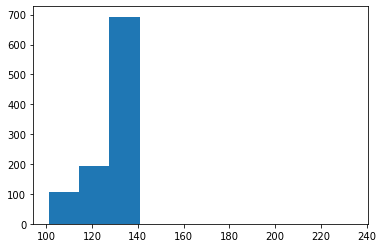

In [23]:
plt.hist(vc_sku)

In [24]:
np.min(vc_sku),np.max(vc_sku)

(101, 234)

## descriptive statistics

**`ord_rev`, `ord_qty`, `cnvrsn_rate` has negative values**

In [25]:
df_gt100.describe()

,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,rvw_cnt,star12_cnt,star12_ratio
count,1.245870e+05,124587.000000,121828.000000,105748.000000,124563.000000,108085.000000,111319.000000,44005.000000,44005.000000,44005.000000
mean,1.292158e+04,83.663713,680.992202,180.463739,3114.358084,0.031209,0.068294,2.991524,0.484854,0.171254
std,6.124485e+04,318.781211,919.062641,107.769601,8392.660454,0.192078,0.208867,4.228691,1.042885,0.313800
min,-1.909576e+05,-683.000000,1.000000,-275.620000,0.000000,-3.000000,0.000000,1.000000,0.000000,0.000000
25%,2.977600e+02,2.000000,140.000000,99.990000,115.000000,0.010612,0.000000,1.000000,0.000000,0.000000
50%,1.979910e+03,13.000000,341.000000,159.990000,834.000000,0.020344,0.000000,2.000000,0.000000,0.000000
75%,9.072950e+03,57.000000,901.000000,239.990000,2951.000000,0.036757,0.015260,3.000000,1.000000,0.250000
max,1.266026e+07,43825.000000,24047.000000,1429.460000,871072.000000,49.000000,1.000000,106.000000,30.000000,1.000000


In [26]:
NA_df_gt100 = dict()
cols = df_gt100.columns
for col in cols:
    NA_df_gt100[col] = sum(df_gt100[col].isna())

In [27]:
NA_df_gt100

{'asin': 0,
 'prdct_title': 0,
 'ord_rev': 0,
 'ord_qty': 0,
 'sale_rank': 2759,
 'avg_price': 18839,
 'gv': 24,
 'cnvrsn_rate': 16502,
 'rep_oos': 13268,
 'zinus_sku': 0,
 'collection': 0,
 'profile': 40814,
 'size': 17029,
 'rvw_cnt': 80582,
 'star12_cnt': 80582,
 'star12_ratio': 80582,
 'year_week': 0}

## drop negative values

In [28]:
rows_to_drop = (df_gt100.ord_rev < 0) | (df_gt100.ord_qty <0) | (df_gt100.cnvrsn_rate <0)
sum(rows_to_drop)

877

In [29]:
neg_idx = rows_to_drop[rows_to_drop].index

In [30]:
df_gt100.loc[neg_idx]

,asin,prdct_title,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,zinus_sku,collection,profile,size,rvw_cnt,star12_cnt,star12_ratio,year_week
395,B079P6NBXZ,Zinus Gel Memory Foam 3 Inch Tri-Fold Comfort ...,-52.11,-1,202,52.11,0,NaN,0.0,AZ-TRI-3S,TRI,3 Inch,Single,<NA>,<NA>,NaN,2020-01-05
46386,B06WVXTGVH,Zinus 12 Inch Foam and Spring Mattress / Certi...,-1.72,0,237,NaN,488,0.000000,0.0,OLB-BNSM-12K,OLB BNSM,12 inch,King,<NA>,<NA>,NaN,2020-09-13
46435,B071CLRK9G,Zinus Van 16 Inch Metal Platform Bed Frame wit...,-275.62,1,70,-275.62,6552,0.000153,0.0,AZ-MPRC-16K,MPRC,14 Inch,King,8,1,0.125,2020-09-13
46556,B06XHTZ74K,ZINUS SmartBase Bed Skirt / 14 Inch Drop / For...,-45.57,-3,<NA>,15.19,0,NaN,NaN,OLB-EBS-14TXL,OLB EBS,14 Inch,Twin XL,1,1,1.000,2020-09-13
46561,B07KK7BQ1G,Zinus Deluxe Mid-Century Wood Platform Bed wit...,-270.47,-1,324,270.47,0,NaN,1.0,SWPBBHM-12Q,SWPBBHM,14 Inch,Queen,<NA>,<NA>,NaN,2020-09-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172871,B07B9LWFPG,ZINUS Moiz Deluxe Wood Platform Bed Frame / Wo...,-184.70,-1,450,184.70,0,NaN,NaN,OLB-RWPBB-14F,OLB RWPBB,14 Inch,Full,<NA>,<NA>,NaN,2022-06-12
173153,B07CYN5CCX,Zinus 6 Inch Mint Green Memory Foam Hybrid Spr...,-244.43,-1,<NA>,244.43,0,NaN,1.0,AZ-MGSM-6Q,MGSM,6 Inch,Queen,<NA>,<NA>,NaN,2022-06-12
173229,B006L7RTKU,ZINUS 8 Inch Quilted Pocket Spring Mattress / ...,-214.20,-1,159,214.20,5,-0.200000,0.0,SC-SMT-8Q,SMT,8 Inch,Queen,<NA>,<NA>,NaN,2022-06-12
173530,B07CQN7F7S,ZINUS Luke 59 Inch Black Metal Corner Desk / L...,-357.18,-1,826,357.18,94,-0.010638,0.0,OLB-LD-A59E,OLB LD,None,None,<NA>,<NA>,NaN,2022-06-12


In [31]:
df_gt100.drop(index=neg_idx,axis=0, inplace=True)

In [32]:
df_gt100.describe()

,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,rvw_cnt,star12_cnt,star12_ratio
count,1.237100e+05,123710.000000,121037.000000,104932.000000,123687.000000,107617.000000,110463.000000,43826.000000,43826.000000,43826.000000
mean,1.301825e+04,84.280147,680.160356,180.323095,3134.437726,0.031658,0.065483,2.996144,0.485442,0.171162
std,6.144803e+04,319.817877,916.620435,107.629773,8418.069995,0.191773,0.202871,4.235332,1.044183,0.313586
min,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,3.136750e+02,2.000000,139.000000,99.990000,120.000000,0.010728,0.000000,1.000000,0.000000,0.000000
50%,2.023000e+03,13.000000,340.000000,159.921102,848.000000,0.020433,0.000000,2.000000,0.000000,0.000000
75%,9.189067e+03,57.000000,900.000000,239.990000,2976.000000,0.036903,0.015085,3.000000,1.000000,0.250000
max,1.266026e+07,43825.000000,24047.000000,1429.460000,871072.000000,49.000000,1.000000,106.000000,30.000000,1.000000


In [33]:
len(df_gt100.zinus_sku.unique())

997

## Replacing NA

* `avg_price` : ffill
* `sale_rank` : ffill
* `cnvrsn_rate` : ffill

* `gv` : 0
* `rep_oos` : 0
* `rvw_cnt` : 0
* `star12_cnt` : 0
* `star12_ratio` : 0

### date range and filling

In [34]:
dt_rg = pd.date_range(start='2020-01-05',end='2022-06-12',freq='W')
dt_rg.name='year_week'

In [35]:
df_gt100.columns

Index(['asin', 'prdct_title', 'ord_rev', 'ord_qty', 'sale_rank', 'avg_price',
       'gv', 'cnvrsn_rate', 'rep_oos', 'zinus_sku', 'collection', 'profile',
       'size', 'rvw_cnt', 'star12_cnt', 'star12_ratio', 'year_week'],
      dtype='object')

In [36]:
df_gt100.sort_index(inplace=True)

In [37]:
df_set = pd.DataFrame(columns=df_gt100.columns)

for k,sku in enumerate(sku_gt_100):
    print('Working %d/%d...' % ((k+1),len(sku_gt_100)), end='\r')
    src_df = df_gt100[df_gt100.zinus_sku==sku].set_index('year_week')
    tmp_df = pd.DataFrame(index=dt_rg)
    tmp_df = tmp_df.join(src_df)
    
    # For meaningfull ffill(), need to fill '0' first row.
    tmp_df[:1] = tmp_df[:1].fillna(0)
    
    tmp_df['zinus_sku'] = np.repeat(src_df.zinus_sku.unique(),tmp_df.shape[0])
    tmp_df['collection'] = np.repeat(src_df.collection.unique(),tmp_df.shape[0])
    tmp_df['profile'] = np.repeat(src_df.profile.unique(),tmp_df.shape[0])
    
    # More than 128 samples should be treated
    tmp_df_m = tmp_df.resample('W-Sun').mean() 
    #lost_cols = list(set(tmp_df.columns)-set(tmp_df_m))
    lost_cols=['zinus_sku','collection','profile']
    
    tmp_df_m.reset_index(inplace=True)
    tmp_df.reset_index(inplace=True)
    tmp_df_m[lost_cols] = tmp_df[lost_cols]
    
    tmp_df_m[['ord_rev', 'ord_qty']] = \
            tmp_df_m[['ord_rev', 'ord_qty']].ffill()
    tmp_df_m[['sale_rank','avg_price', 'cnvrsn_rate']] = \
            tmp_df_m[['sale_rank', 'avg_price', 'cnvrsn_rate']].ffill()
    tmp_df_m[['gv','rep_oos', 'rvw_cnt','star12_cnt', 'star12_ratio']] = \
            tmp_df_m[['gv','rep_oos', 'rvw_cnt','star12_cnt', 'star12_ratio']].fillna(0)
    
    df_set = df_set.append(tmp_df_m)
    del tmp_df, tmp_df_m

In [38]:
df_gt100.shape

(123710, 17)

In [39]:
df_set.shape

(127616, 17)

In [40]:
df_set.zinus_sku.unique()

array(['OLB-SWPB-12T', 'SC-BTCM-8Q', 'SC-SPP-10SQ', 'SC-SMT-8TXL',
       'OLB-MGT-150F', 'OLB-BNSM-6F', 'AZ-SBF-07Q', 'AZ-HDBF-7T',
       'AZ-SBF-07CK', 'AZ-HDBF-7CK', 'AZ-SBF-07U', 'AZ-SBF-07T',
       'AZ-SBF-07F', 'AZ-SBF-07K', 'OLB-SBF-U2', 'OLB-ABS-7F',
       'OLB-ABS-7K', 'OLB-ABS-7T', 'OLB-ABS-7Q', 'AZ-HDBF-7U1',
       'AZ-HDBF-7U2', 'OLB-ABS-7TXL', 'OLB-ABS-7CK', 'OLB-SSBFH-7F',
       'OLB-SSBFH-7K', 'OLB-SSBFH-7T', 'FTTP-F', 'OLB-FGM-0600SQ',
       'FTTP-K', 'OLB-GTFM-6N', 'M-FMS-600F', 'M-FMS-600T',
       'OLB-BNSM-6SQ', 'M-FMS-600Q', 'OLB-GTFM-6F', 'OLB-GTFM-6K',
       'OLB-GTFM-6T', 'OLB-GTFM-6Q', 'EFPB-Q', 'OLB-GTFM-6SQ',
       'OLB-SSBF-7F', 'IRPF-6K', 'IRPF-6Q', 'OLB-FGM-0600F',
       'OLB-FGM-0600T', 'OLB-FGM-0600Q', 'OLB-MBBF-6F', 'OLB-MBBF-6K',
       'OLB-MBBF-6T', 'OLB-MBBF-6Q', 'OLB-SSBFH-7Q', 'OLB-SSBF-7Q',
       'OLB-SSBF-7T', 'OLB-GTFM-8Q', 'CSPB-T-Q', 'AZ-MGSM-8Q',
       'OLB-BNSM-8F', 'FHCP-Q', 'OLB-BNSM-8Q', 'OLB-BNSM-8SQ',
       'OLB-GTFM-8F', '

In [41]:
df_set[['zinus_sku','year_week']].groupby('zinus_sku').agg('count')

,year_week
zinus_sku,
ADB-14Q,128
ADB-14TXL,128
AZ-ASMP-10F,128
AZ-ASMP-10K,128
AZ-ASMP-10Q,128
...,...
ZU-TMTCCS-02T,128
ZU-TMTCCS-03F,128
ZU-TMTCCS-03K,128


In [42]:
df_set.zinus_sku.value_counts()

OLB-SWPB-12T      128
CLSB-14F          128
W-BSLB-T          128
OLB-IRPBHB-14F    128
OLB-SMPB-14Q      128
                 ... 
ESBS-9F           128
ESBS-9K           128
FGPP-K            128
FRBX-9GR-F        128
FBMCMP-12K        128
Name: zinus_sku, Length: 997, dtype: int64

## Inch inforamtion

In [52]:
df_gt100.collection.unique()

array(['OLB MGT', 'SWFT', 'GTFT', 'TGTCCM', 'SPP', 'MGSM', 'FMS', 'ASMPH',
       'OLB GTFM', 'SBBK', 'CMM', 'HBSM', 'OLB FGM', 'OLB MBBF', 'ASMP',
       'OLB PPSM', 'OLB BNSM', 'SWPBB', 'OLB SMPB', 'OLB PWPBHE', 'SBF',
       'OLB PWPBBHE', 'OLB QLPBHFB', 'OLB QLPBHF', 'OLIVE OIL', 'SWPBBA',
       'SWPBBHA', 'SWPBBHF', 'HBPBA', 'HBPBB', 'SWPBBHG', 'SWPBBHW',
       'HBPBE', 'MPRC', 'OLB EBS', 'ASMPCH', 'OLB RWPBD', 'OLB SWPBHC',
       'OLB RWPB', 'SWPBBHM', 'OLB SWPBHT', 'QCMP', 'MPSC', 'OLB SWPBHR',
       'QSMP', 'OLB RPPBC', 'OLB RWPBB', 'OLB IRPBHB', 'OLB SBST',
       'OLB RPPBA', 'PRSK', 'IRPF', 'QCMPH', 'OLB QLSP', 'OLB SWPB',
       'CLSB', 'OLB ASB', 'OLB SWPBB', 'SB13', 'OLB IRPBH', 'ADB', 'SB',
       'OLB SB13', 'TRI', 'OLB PWPBE', 'OLB PWPBHO', 'OLB PWPBO', 'ESBS',
       'FRBX', 'OLB WDBS', 'OLB BIFD', 'OLB QLBS', 'HBBS', 'FMSB', 'FMSP',
       'OLB ABS', 'SBLP', 'OLB SSM', 'WDBF', 'OLB PWPBBHO', 'OLB PWPBBO',
       'OLB PWPBBE', 'OLB SWPBBHS', 'HDBF', 'OLB SBF', 'OL

In [44]:
coll_inch = df_gt100[['collection','profile']].pivot_table(index='collection',columns='profile',aggfunc=np.unique)
coll_inch

profile,1.25 Inch,1.5 Inch,10 Inch,12 inch,13 Inch,14 Inch,16 Inch,18 Inch,2 Inch,3 Inch,3.5 Inch,4 Inch,5 Inch,5.75 Inch,6 Inch,7 Inch,7.5 Inch,8 Inch,9 Inch
collection,,,,,,,,,,,,,,,,,,,
ADB,NaN,NaN,NaN,NaN,NaN,"[14 Inch, ADB]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASMP,NaN,NaN,"[10 Inch, ASMP]",NaN,NaN,"[14 Inch, ASMP]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASMPCH,NaN,NaN,NaN,NaN,NaN,"[14 Inch, ASMPCH]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASMPH,NaN,NaN,"[10 Inch, ASMPH]",NaN,NaN,"[14 Inch, ASMPH]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BIFD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[7.5 Inch, BIFD]",NaN,"[9 Inch, BIFD]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTCCM,NaN,"[1.5 Inch, TGTCCM]",NaN,NaN,NaN,NaN,NaN,NaN,"[2 Inch, TGTCCM]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TGTSCG,NaN,"[1.5 Inch, TGTSCG]",NaN,NaN,NaN,NaN,NaN,NaN,"[2 Inch, TGTSCG]","[3 Inch, TGTSCG]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TMTCCS,"[1.25 Inch, TMTCCS]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[2 Inch, TMTCCS]","[3 Inch, TMTCCS]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Modeling (interaction terms from GA2M)

Microsoft EBM package (https://interpret.ml/docs/ebm.html)

## For a SKU

In [45]:
from interpret import set_visualize_provider, show
from interpret.provider import InlineProvider
from interpret.glassbox import ExplainableBoostingRegressor

set_visualize_provider(InlineProvider())

In [46]:
df_set.zinus_sku.value_counts()

OLB-SWPB-12T      128
CLSB-14F          128
W-BSLB-T          128
OLB-IRPBHB-14F    128
OLB-SMPB-14Q      128
                 ... 
ESBS-9F           128
ESBS-9K           128
FGPP-K            128
FRBX-9GR-F        128
FBMCMP-12K        128
Name: zinus_sku, Length: 997, dtype: int64

In [47]:
tmp_df_set = df_set[df_set.zinus_sku=='OLB-SWPB-12T']

In [48]:
tmp_df_set.year_week.value_counts()

2020-01-05    1
2020-01-12    1
2021-10-24    1
2021-10-17    1
2021-10-10    1
             ..
2020-09-20    1
2020-09-13    1
2020-09-06    1
2020-08-30    1
2022-06-12    1
Name: year_week, Length: 128, dtype: int64

In [49]:
tmp_df_set

,asin,prdct_title,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,zinus_sku,collection,profile,size,rvw_cnt,star12_cnt,star12_ratio,year_week
0,NaN,NaN,1082.990,9.0,262.0,120.332222,1321.0,0.006813,0.0,OLB-SWPB-12T,OLB SWPB,14 Inch,NaN,0.0,0.0,0.0,2020-01-05
1,NaN,NaN,1867.990,16.0,262.0,116.749375,1380.0,0.011594,0.0,OLB-SWPB-12T,OLB SWPB,14 Inch,NaN,0.0,0.0,0.0,2020-01-12
2,NaN,NaN,760.500,6.5,250.0,117.000000,837.5,0.007761,0.0,OLB-SWPB-12T,OLB SWPB,14 Inch,NaN,1.0,0.0,0.0,2020-01-19
3,NaN,NaN,637.430,5.5,245.0,115.896364,471.5,0.011665,0.0,OLB-SWPB-12T,OLB SWPB,14 Inch,NaN,0.0,0.0,0.0,2020-01-26
4,NaN,NaN,643.500,5.5,254.0,117.000000,445.5,0.012346,0.0,OLB-SWPB-12T,OLB SWPB,14 Inch,NaN,0.0,0.0,0.0,2020-02-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,NaN,NaN,5832.320,46.5,1709.0,144.820000,791.0,0.042331,0.0,OLB-SWPB-12T,OLB SWPB,14 Inch,NaN,0.0,0.0,0.0,2022-05-15
124,NaN,NaN,3187.500,25.5,1565.0,125.000000,572.5,0.044541,0.0,OLB-SWPB-12T,OLB SWPB,14 Inch,NaN,0.0,0.0,0.0,2022-05-22
125,NaN,NaN,1250.000,10.0,273.0,125.000000,656.0,0.015244,0.0,OLB-SWPB-12T,OLB SWPB,14 Inch,NaN,0.0,0.0,0.0,2022-05-29
126,NaN,NaN,516.525,3.0,1241.5,172.175000,290.0,0.010345,0.0,OLB-SWPB-12T,OLB SWPB,14 Inch,NaN,0.0,0.0,0.0,2022-06-05


### Train and Test

In [50]:
features = ['star12_cnt','star12_ratio', 'rep_oos', 'gv', 'sale_rank', 'cnvrsn_rate', 'avg_price', 'rvw_cnt']

In [51]:
features.pop(features.index('ord_rev')) # target
features.pop(features.index('ord_qty')) # drop to use
features.pop(features.index('year_week')) # will set index
features

ValueError: 'ord_rev' is not in list

In [ ]:
tmp_df_set.set_index('year_week',inplace=True)

In [ ]:
tSize = 24 # approx. 6 month
X = tmp_df_set[features]
y = tmp_df_set.ord_rev

seed=42
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)
X_train=X.iloc[:-tSize,]
X_test=X.iloc[-tSize:,]
y_train=y.iloc[:-tSize]
y_test=y.iloc[-tSize:]
ebm = ExplainableBoostingRegressor(random_state=seed)
ebm.fit(X_train, y_train)

ebm_global = ebm.explain_global()
show(ebm_global)

### Performance

In [ ]:
# Return the coefficient of determination R^2 of the prediction(Per documents)
ebm.score(X_test,y_test)

In [ ]:
plotting_predictions(y_train,pd.Series(ebm.predict(X_train),index=X_train.index),'Training Prediction')

In [ ]:
plotting_predictions(y_test,pd.Series(ebm.predict(X_test),index=X_test.index),'Test Prediction')

### Feature Importance

In [ ]:
# Definition of importance : see https://github.com/interpretml/interpret/issues/12
df_imp = pd.DataFrame(np.round(ebm.feature_importances_,0),\
             index=ebm.feature_names,columns=['importance']).sort_values(by='importance',ascending=False)
df_imp

In [ ]:
df_imp_cum = (df_imp/df_imp.sum()).round(3).cumsum()
df_imp_cum

### Feature reduction up to 95% of importance

In [ ]:
len(df_imp.index)

In [ ]:
features_red = df_imp_cum[df_imp_cum.importance<0.95].index
len(features_red)

In [ ]:
features_red

### Any interactions?

In [ ]:
[x for x in feature_red if x.__contains__(' x ')]

## Whole SKUs

In [714]:
SKUs = df_set.zinus_sku.unique()

In [715]:
perf_cols = ['sku','rmse','mape','r2','imp95','ebm_model']
df_ebm_all = pd.DataFrame(columns= perf_cols,index=range(len(SKUs)))

for k,sku in enumerate(SKUs):
    print('Working %d/%d...' % ((k+1),len(SKUs)), end='\r')
    tmp_df_set = df_set[df_set.zinus_sku==sku]
    tmp_df_set.set_index('year_week',inplace=True)

    X = tmp_df_set[features]
    y = tmp_df_set.ord_rev

    ebm = ExplainableBoostingRegressor(random_state=seed)
    ebm.fit(X, y)
    
    # Metrics for training set (100%)
    rmse,mape,r2 = metrics_time_series(y,pd.Series(ebm.predict(X),index=X.index),verbose=False)
    
    # Feature importance
    df_imp = pd.DataFrame(np.round(ebm.feature_importances_,0),\
             index=ebm.feature_names,columns=['importance']).sort_values(by='importance',ascending=False)
    df_imp_cum = (df_imp/df_imp.sum()).round(3).cumsum()
    df_imp95_raw = df_imp[df_imp_cum.importance<0.95]
    imp95 = (df_imp95_raw/df_imp95_raw.sum()).round(3).to_dict()['importance']
    
    df_ebm_all.loc[k] = {'sku':sku,'rmse':rmse,'mape':mape,'r2':r2,'imp95':imp95,'ebm_model':ebm}

In [716]:
df_ebm_all

,sku,rmse,mape,r2,imp95,ebm_model
0,OLB-SWPB-12T,493.39,25.96,0.92,"{'gv': 0.266, 'cnvrsn_rate': 0.235, 'sale_rank...",ExplainableBoostingRegressor(feature_names=['s...
1,SC-BTCM-8Q,1171.72,6.61,0.99,"{'gv': 0.309, 'cnvrsn_rate': 0.118, 'sale_rank...",ExplainableBoostingRegressor(feature_names=['s...
2,SC-SPP-10SQ,497.46,23.43,0.98,"{'gv': 0.532, 'cnvrsn_rate': 0.155, 'avg_price...",ExplainableBoostingRegressor(feature_names=['s...
3,SC-SMT-8TXL,65.18,17.4,0.93,"{'gv': 0.451, 'sale_rank': 0.136, 'cnvrsn_rate...",ExplainableBoostingRegressor(feature_names=['s...
4,OLB-MGT-150F,49.3,9.84,0.98,"{'gv': 0.3, 'cnvrsn_rate': 0.177, 'sale_rank':...",ExplainableBoostingRegressor(feature_names=['s...
...,...,...,...,...,...,...
992,ZU-TMTCCS-01F,53.05,20.3,0.97,"{'gv': 0.297, 'cnvrsn_rate': 0.203, 'avg_price...",ExplainableBoostingRegressor(feature_names=['s...
993,FTTP-DG-K,307.62,15.54,0.97,"{'gv': 0.326, 'sale_rank': 0.12, 'cnvrsn_rate'...",ExplainableBoostingRegressor(feature_names=['s...
994,FRBX-4NV-F,97.35,24.46,0.83,"{'gv': 0.492, 'cnvrsn_rate': 0.185, 'avg_price...",ExplainableBoostingRegressor(feature_names=['s...
995,FLPB-K,77.28,10.74,0.99,"{'gv': 0.394, 'cnvrsn_rate': 0.177, 'avg_price...",ExplainableBoostingRegressor(feature_names=['s...


# Assesement 

## R2 (Note : Training predictions)

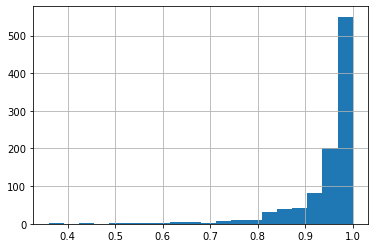

In [750]:
df_ebm_all.r2.hist(bins=20)
plt.show()

In [721]:
df_ebm_all.r2.value_counts()

0.99    242
0.98    167
0.97    110
0.96     83
0.95     70
0.94     47
0.93     34
1.00     31
0.91     28
0.92     21
0.89     15
0.88     15
0.83     14
0.85     13
0.90     11
0.82     10
0.87      9
0.86      9
0.84      7
0.81      7
0.80      5
0.72      5
0.76      4
0.71      3
0.67      3
0.75      3
0.78      3
0.63      2
0.56      2
0.73      2
0.79      2
0.54      2
0.62      2
0.77      2
0.51      2
0.66      2
0.57      1
0.44      1
0.36      1
0.64      1
0.52      1
0.60      1
0.74      1
0.37      1
0.65      1
0.49      1
Name: r2, dtype: int64

In [722]:
sum(df_ebm_all.r2<0.90)

153

In [747]:
skus_r2_gt_90 = df_ebm_all[df_ebm_all.r2 >= 0.90].sku.tolist()
skus_r2_lt_90 = df_ebm_all[df_ebm_all.r2 < 0.90].sku.tolist()

In [748]:
print(len(skus_r2_gt_90),len(skus_r2_lt_90))

844 153


## Price is a predictor?

In [737]:
price_imp = [x['avg_price'] for x in df_ebm_all.imp95 if 'avg_price' in x.keys()]
price_imp

[0.063,
 0.084,
 0.098,
 0.094,
 0.123,
 0.133,
 0.067,
 0.061,
 0.051,
 0.119,
 0.166,
 0.074,
 0.113,
 0.076,
 0.105,
 0.088,
 0.072,
 0.108,
 0.064,
 0.124,
 0.092,
 0.094,
 0.088,
 0.089,
 0.082,
 0.108,
 0.079,
 0.118,
 0.082,
 0.078,
 0.135,
 0.066,
 0.088,
 0.136,
 0.167,
 0.155,
 0.103,
 0.111,
 0.155,
 0.086,
 0.106,
 0.151,
 0.087,
 0.089,
 0.098,
 0.08,
 0.144,
 0.091,
 0.13,
 0.165,
 0.067,
 0.161,
 0.097,
 0.08,
 0.097,
 0.106,
 0.085,
 0.144,
 0.09,
 0.16,
 0.132,
 0.14,
 0.076,
 0.084,
 0.084,
 0.07,
 0.122,
 0.086,
 0.134,
 0.216,
 0.133,
 0.155,
 0.064,
 0.115,
 0.098,
 0.072,
 0.13,
 0.125,
 0.102,
 0.137,
 0.149,
 0.154,
 0.073,
 0.101,
 0.085,
 0.044,
 0.172,
 0.087,
 0.104,
 0.102,
 0.098,
 0.158,
 0.126,
 0.079,
 0.086,
 0.185,
 0.107,
 0.108,
 0.086,
 0.075,
 0.113,
 0.126,
 0.092,
 0.066,
 0.058,
 0.099,
 0.019,
 0.233,
 0.06,
 0.154,
 0.133,
 0.106,
 0.094,
 0.179,
 0.098,
 0.089,
 0.091,
 0.054,
 0.084,
 0.083,
 0.139,
 0.132,
 0.091,
 0.135,
 0.14,
 0.168,
 0

### Most of the SKU has `avg_price` as a predictor

In [738]:
len(price_imp)

994

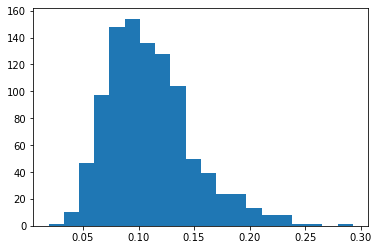

In [739]:
plt.hist(price_imp,bins=20)
plt.show()

### SKUs of R2 < 0.9

In [744]:
price_imp_r2_lt_90 = [x['avg_price'] for x in \
                      df_ebm_all[df_ebm_all.sku.isin(skus_r2_lt_90)]['imp95'] if 'avg_price' in x.keys()]
price_imp_r2_lt_90

[0.108,
 0.136,
 0.167,
 0.067,
 0.106,
 0.076,
 0.086,
 0.155,
 0.154,
 0.098,
 0.092,
 0.154,
 0.084,
 0.139,
 0.132,
 0.077,
 0.157,
 0.131,
 0.19,
 0.096,
 0.073,
 0.219,
 0.061,
 0.077,
 0.104,
 0.096,
 0.104,
 0.203,
 0.145,
 0.15,
 0.171,
 0.208,
 0.111,
 0.119,
 0.142,
 0.09,
 0.128,
 0.13,
 0.115,
 0.142,
 0.11,
 0.078,
 0.106,
 0.123,
 0.113,
 0.124,
 0.092,
 0.149,
 0.145,
 0.103,
 0.064,
 0.101,
 0.093,
 0.094,
 0.087,
 0.081,
 0.08,
 0.181,
 0.12,
 0.13,
 0.121,
 0.195,
 0.167,
 0.054,
 0.106,
 0.119,
 0.111,
 0.141,
 0.085,
 0.101,
 0.114,
 0.162,
 0.128,
 0.094,
 0.059,
 0.136,
 0.106,
 0.109,
 0.178,
 0.048,
 0.125,
 0.162,
 0.086,
 0.093,
 0.06,
 0.105,
 0.098,
 0.102,
 0.069,
 0.128,
 0.087,
 0.093,
 0.061,
 0.13,
 0.138,
 0.197,
 0.137,
 0.089,
 0.107,
 0.063,
 0.14,
 0.128,
 0.12,
 0.056,
 0.099,
 0.078,
 0.069,
 0.104,
 0.172,
 0.069,
 0.061,
 0.123,
 0.159,
 0.134,
 0.099,
 0.106,
 0.259,
 0.066,
 0.122,
 0.172,
 0.108,
 0.114,
 0.128,
 0.094,
 0.214,
 0.205,
 0.1

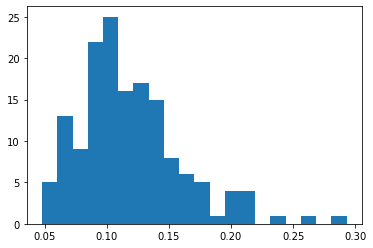

In [746]:
plt.hist(price_imp_r2_lt_90,bins=20)
plt.show()

### What about SKUs of R2 > 0.9

In [740]:
price_imp_r2_gt_90 = [x['avg_price'] for x in \
                      df_ebm_all[df_ebm_all.sku.isin(skus_r2_gt_90)]['imp95'] if 'avg_price' in x.keys()]
price_imp_r2_gt_90

[0.063,
 0.084,
 0.098,
 0.094,
 0.123,
 0.133,
 0.067,
 0.061,
 0.051,
 0.119,
 0.166,
 0.074,
 0.113,
 0.076,
 0.105,
 0.088,
 0.072,
 0.064,
 0.124,
 0.092,
 0.094,
 0.088,
 0.089,
 0.082,
 0.108,
 0.079,
 0.118,
 0.082,
 0.078,
 0.135,
 0.066,
 0.088,
 0.155,
 0.103,
 0.111,
 0.155,
 0.086,
 0.106,
 0.151,
 0.087,
 0.089,
 0.098,
 0.08,
 0.144,
 0.091,
 0.13,
 0.165,
 0.161,
 0.097,
 0.08,
 0.097,
 0.085,
 0.144,
 0.09,
 0.16,
 0.132,
 0.14,
 0.084,
 0.084,
 0.07,
 0.122,
 0.134,
 0.216,
 0.133,
 0.064,
 0.115,
 0.098,
 0.072,
 0.13,
 0.125,
 0.102,
 0.137,
 0.149,
 0.073,
 0.101,
 0.085,
 0.044,
 0.172,
 0.087,
 0.104,
 0.102,
 0.158,
 0.126,
 0.079,
 0.086,
 0.185,
 0.107,
 0.108,
 0.086,
 0.075,
 0.113,
 0.126,
 0.066,
 0.058,
 0.099,
 0.019,
 0.233,
 0.06,
 0.133,
 0.106,
 0.094,
 0.179,
 0.098,
 0.089,
 0.091,
 0.054,
 0.083,
 0.091,
 0.135,
 0.14,
 0.168,
 0.081,
 0.107,
 0.135,
 0.092,
 0.161,
 0.074,
 0.11,
 0.097,
 0.076,
 0.077,
 0.067,
 0.113,
 0.184,
 0.137,
 0.063,
 0.

Some SKUs (3) are missing.

In [741]:
print(len(skus_r2_gt_90),len(price_imp_r2_gt_90))

844 841


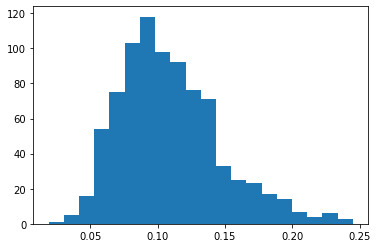

In [742]:
plt.hist(price_imp_r2_gt_90,bins=20)
plt.show()

# OOV (Out of Sample Validation : Cross-Sectional) performance

In [758]:
perf_cols_new = ['sku','rmse_i','mape_i','r2_i','rmse_o','mape_o','r2_o','imp95','ebm_model']
df_ebm_oov = pd.DataFrame(columns= perf_cols_new,index=range(len(SKUs)))

for k,sku in enumerate(SKUs):
    print('Working %d/%d...' % ((k+1),len(SKUs)), end='\r')
    tmp_df_set = df_set[df_set.zinus_sku==sku]
    tmp_df_set.set_index('year_week',inplace=True)

    X = tmp_df_set[features]
    y = tmp_df_set.ord_rev

    # Cross-sectional
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)
    
    # Time-series like
    #tSize = 24 # approx. 6 month
    #X_train=X.iloc[:-tSize,]
    #X_test=X.iloc[-tSize:,]
    #y_train=y.iloc[:-tSize]
    #y_test=y.iloc[-tSize:]
    
    ebm = ExplainableBoostingRegressor(random_state=seed)
    ebm.fit(X_train, y_train)
    
    # Metrics for training set (100%)
    rmse_i,mape_i,r2_i = metrics_time_series(y_train,pd.Series(ebm.predict(X_train),\
                                                               index=X_train.index),verbose=False)
    rmse_o,mape_o,r2_o = metrics_time_series(y_test,pd.Series(ebm.predict(X_test),\
                                                               index=X_test.index),verbose=False)
    
    # Feature importance
    df_imp = pd.DataFrame(np.round(ebm.feature_importances_,0),\
             index=ebm.feature_names,columns=['importance']).sort_values(by='importance',ascending=False)
    df_imp_cum = (df_imp/df_imp.sum()).round(3).cumsum()
    df_imp95_raw = df_imp[df_imp_cum.importance<0.95]
    imp95 = (df_imp95_raw/df_imp95_raw.sum()).round(3).to_dict()['importance']
    
    df_ebm_oov.loc[k] = {'sku':sku,
                         'rmse_i':rmse_i,
                         'mape_i':mape_i,
                         'r2_i':r2_i,
                         'rmse_o':rmse_o,
                         'mape_o':mape_o,
                         'r2_o':r2_o,
                         'imp95':imp95,
                         'ebm_model':ebm}

## R2 diff

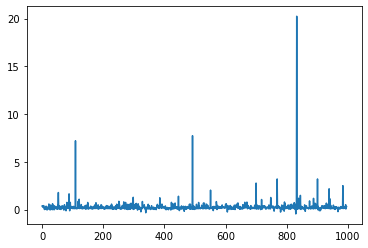

In [787]:
df_ebm_oov['r2_diff'] = df_ebm_oov.r2_i-df_ebm_oov.r2_o
df_ebm_oov.r2_diff.plot()
plt.show()

In [788]:
# SKUs with big negative R2
sum(df_ebm_oov.r2_o < 0)

23

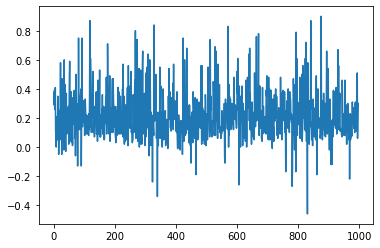

In [790]:
# Excluding that, but shows big difference
df_ebm_oov[df_ebm_oov.r2_o > 0]['r2_diff'].plot()
plt.show()

In [810]:
df_ebm_oov[df_ebm_oov.r2_o > 0]['r2_diff']

0      0.37
1      0.29
2      0.39
3      0.26
4      0.26
       ... 
992    0.11
993    0.51
994    0.06
995    0.21
996     0.3
Name: r2_diff, Length: 973, dtype: object

In [819]:
print('mean \t: ',df_ebm_oov[df_ebm_oov.r2_o > 0]['r2_diff'].mean().round(3), '\n',
      'var  \t: ',df_ebm_oov[df_ebm_oov.r2_o > 0]['r2_diff'].var().round(3), '\n')

mean 	:  0.212 
 var  	:  0.028 



In [796]:
# About 23% of SKU have less than 10% diff
sum(np.abs(df_ebm_oov.r2_diff)<0.1)

230

In [797]:
skus_r2diff_lt_10 = df_ebm_oov[np.abs(df_ebm_oov.r2_diff)<0.1].sku
skus_r2diff_lt_10

6       AZ-SBF-07Q
7       AZ-HDBF-7T
8      AZ-SBF-07CK
10      AZ-SBF-07U
12      AZ-SBF-07F
          ...     
974     MSHPHB-12F
975    OLB-CT-EA44
976     MSHBBT-12Q
985      AZ-FMS-4T
994     FRBX-4NV-F
Name: sku, Length: 230, dtype: object

### SKU with huge difference 

In [785]:
idx = np.argmax(df_ebm_oov[df_ebm_oov.r2_o < 0]['r2_diff'])
df_ebm_oov[df_ebm_oov.r2_o < 0].iloc[idx]

sku                                              ZU-TMTCCS-03K
rmse_i                                                 1736.29
mape_i                                                   64.68
r2_i                                                      0.73
rmse_o                                                  980.62
mape_o                                                  235.74
r2_o                                                    -19.51
imp95        {'avg_price': 0.244, 'sale_rank': 0.202, 'cnvr...
ebm_model    ExplainableBoostingRegressor(feature_names=['s...
r2_diff                                                  20.24
Name: 833, dtype: object

In [778]:
df_set[df_set.zinus_sku=='ZU-TMTCCS-03K'].ord_rev

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
       ...  
123      0.0
124    120.5
125    361.5
126    241.0
127    241.0
Name: ord_rev, Length: 128, dtype: float64

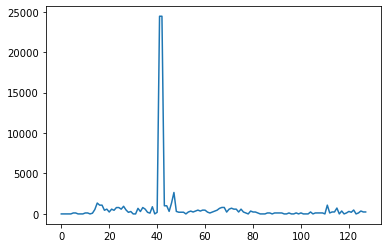

In [824]:
df_set[df_set.zinus_sku=='ZU-TMTCCS-03K'].ord_rev.plot()
plt.show()

In [825]:
sum(df_set[df_set.zinus_sku=='ZU-TMTCCS-03K'].ord_rev==0.0)

31

# OOVT (Out of Sample Validation : Time-aware) performance

In [798]:
perf_cols_new = ['sku','rmse_i','mape_i','r2_i','rmse_o','mape_o','r2_o','imp95','ebm_model']
df_ebm_oovt = pd.DataFrame(columns= perf_cols_new,index=range(len(SKUs)))

tSize = 24 # approx. 6 month
    
for k,sku in enumerate(SKUs):
    print('Working %d/%d...' % ((k+1),len(SKUs)), end='\r')
    tmp_df_set = df_set[df_set.zinus_sku==sku]
    tmp_df_set.set_index('year_week',inplace=True)

    X = tmp_df_set[features]
    y = tmp_df_set.ord_rev

    # Time-series like

    X_train=X.iloc[:-tSize,]
    X_test=X.iloc[-tSize:,]
    y_train=y.iloc[:-tSize]
    y_test=y.iloc[-tSize:]
    
    ebm = ExplainableBoostingRegressor(random_state=seed)
    ebm.fit(X_train, y_train)
    
    # Metrics for training set (100%)
    rmse_i,mape_i,r2_i = metrics_time_series(y_train,pd.Series(ebm.predict(X_train),\
                                                               index=X_train.index),verbose=False)
    rmse_o,mape_o,r2_o = metrics_time_series(y_test,pd.Series(ebm.predict(X_test),\
                                                               index=X_test.index),verbose=False)
    
    # Feature importance
    df_imp = pd.DataFrame(np.round(ebm.feature_importances_,0),\
             index=ebm.feature_names,columns=['importance']).sort_values(by='importance',ascending=False)
    df_imp_cum = (df_imp/df_imp.sum()).round(3).cumsum()
    df_imp95_raw = df_imp[df_imp_cum.importance<0.95]
    imp95 = (df_imp95_raw/df_imp95_raw.sum()).round(3).to_dict()['importance']
    
    df_ebm_oovt.loc[k] = {'sku':sku,
                         'rmse_i':rmse_i,
                         'mape_i':mape_i,
                         'r2_i':r2_i,
                         'rmse_o':rmse_o,
                         'mape_o':mape_o,
                         'r2_o':r2_o,
                         'imp95':imp95,
                         'ebm_model':ebm}

## R2 diff

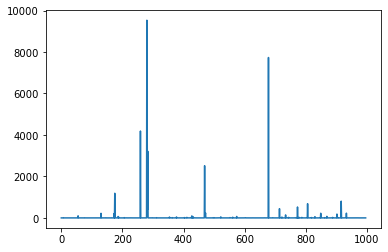

In [800]:
df_ebm_oovt['r2_diff'] = df_ebm_oovt.r2_i-df_ebm_oovt.r2_o
df_ebm_oovt.r2_diff.plot()
plt.show()

In [801]:
# SKUs with big negative R2
sum(df_ebm_oovt.r2_o < 0)

262

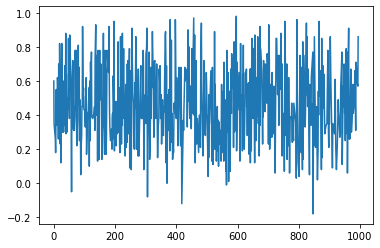

In [802]:
# Excluding that, but shows big difference
df_ebm_oovt[df_ebm_oovt.r2_o > 0]['r2_diff'].plot()
plt.show()

In [803]:
df_ebm_oovt[df_ebm_oovt.r2_o > 0]['r2_diff']

0       0.6
1      0.35
5      0.26
6      0.18
8      0.55
       ... 
987    0.71
990    0.64
991    0.59
993    0.57
994    0.86
Name: r2_diff, Length: 671, dtype: object

In [820]:
print('mean \t: ',df_ebm_oovt[df_ebm_oovt.r2_o > 0]['r2_diff'].mean().round(3), '\n',
      'var  \t: ',df_ebm_oovt[df_ebm_oovt.r2_o > 0]['r2_diff'].var().round(3), '\n')

mean 	:  0.463 
 var  	:  0.051 



In [804]:
# About 2.7% of SKU have less than 10% diff
sum(np.abs(df_ebm_oovt.r2_diff)<0.1)

26

In [805]:
skus_Tr2diff_lt_10 = df_ebm_oov[np.abs(df_ebm_oov.r2_diff)<0.1].sku
skus_Tr2diff_lt_10

6       AZ-SBF-07Q
7       AZ-HDBF-7T
8      AZ-SBF-07CK
10      AZ-SBF-07U
12      AZ-SBF-07F
          ...     
974     MSHPHB-12F
975    OLB-CT-EA44
976     MSHBBT-12Q
985      AZ-FMS-4T
994     FRBX-4NV-F
Name: sku, Length: 230, dtype: object

### SKU with huge difference 

In [806]:
idx = np.argmax(df_ebm_oovt[df_ebm_oovt.r2_o < 0]['r2_diff'])
df_ebm_oovt[df_ebm_oovt.r2_o < 0].iloc[idx]

sku                                                     BSLV-F
rmse_i                                                 2585.44
mape_i                                                  178.92
r2_i                                                      0.89
rmse_o                                                 3453.33
mape_o                                                  3523.5
r2_o                                                  -9531.52
imp95        {'gv': 0.265, 'cnvrsn_rate': 0.189, 'avg_price...
ebm_model    ExplainableBoostingRegressor(feature_names=['s...
r2_diff                                                9532.41
Name: 280, dtype: object

In [807]:
df_set[df_set.zinus_sku=='BSLV-F'].ord_rev

0      6332.15
1      7308.75
2      6440.14
3      4394.82
4      3875.80
        ...   
123       0.00
124       0.00
125       0.00
126       0.00
127     108.92
Name: ord_rev, Length: 128, dtype: float64

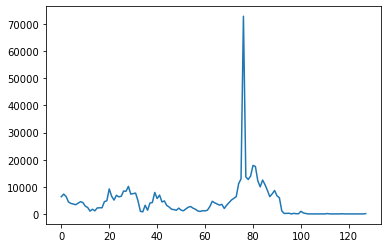

In [809]:
df_set[df_set.zinus_sku=='BSLV-F'].ord_rev.plot()
plt.show()

In [818]:
sum(df_set[df_set.zinus_sku=='BSLV-F'].ord_rev==0.0)

22

# Save performance files

In [826]:
df_ebm_all.to_pickle('df_ebm_all.pickle')

In [827]:
df_ebm_oov.to_pickle('df_ebm_oov.pickle')

In [828]:
df_ebm_oovt.to_pickle('df_ebm.oovt.pickle')